Hello! This was my final project for my ASTR2600 at CU Boulder in the summer of 25. In this notebook I explore gravitational n-body systems using leagfrog code.

At the end of the notebook, I randomly generate a system of stars orbiting a black hole using monte carlo and the leap frog code.

#### modules

In [ ]:
import forces # Tatsuya Akiba's forces package

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
from mpl_toolkits import mplot3d
import matplotlib.animation as ani

### 5.2 (Leapfrog Code)

breakdown
1) calculate starting forces
2) calculate starting acceleration using starting forces
3) calculate end position using starting acceleration and starting velocity
4) calculate end forces using end positions
5) calculate end acceleration using end forces
6) calculate end velocity

In [ ]:
def leapfrogStep(masses, positions, velocities, stepsize):
    '''
    Calculates the next positions, velocities, accelerations, and forces for an array of massive particles.
        It is a single time step.
    ------------
    Input:  array of masses, in kg
            array of position vector arrays in the format [x,y,z], in meters
            array of velocity vector arrays in the format [x,y,z, in m/s
            a determined step size for the increase in time, in seconds
    ------------
    Output: a tuple of two 2D arrays representing the new positions and
            velocities of the particles after the time step
    '''
    # import modules in my function just in case I forget to at the global level
    import numpy as np

    #convert positions and velocities to arrays, in case they aren't already
    start_positions = np.array(positions)
    start_velocities = np.array(velocities)
    #^these should both be 2D arrays

    #how many particles?
    # _ indicates we don't care about any value other than shape
    num_particles, _ = start_positions.shape

    # errors in case the input arrays have different shapes or number of particles

    if start_velocities.shape != start_positions.shape:
        raise ValueError("Velocities and Positions have different shapes")

    if len(masses) != num_particles:
        raise ValueError("Length of masses differs from the first dimension of positions")

    #Calculate starting forces
    start_forces = forces.calculateForceVectors(masses, start_positions)

    #calculate starting acceleration
    start_accelerations = []
    for m in range(len(start_forces)):
        start_accelerations.append(start_forces[m]/masses[m])

    start_accelerations = np.array(start_accelerations) #make it an array

    #calculate end positions
    end_positions = start_positions + start_velocities*stepsize + (1.0/2.0)*(start_accelerations)*(stepsize**2)


    #Calculate end forces
    end_forces = forces.calculateForceVectors(masses, end_positions)


    #calculate the end accelerations
    end_accelerations = []
    for n in range(len(end_forces)):
        end_accelerations.append(end_forces[n]/masses[n])

    end_accelerations = np.array(end_accelerations) #make it an array

    #calculate ending velcocity
    end_velocities = start_velocities + (1.0/2.0)*(start_accelerations + end_accelerations)*(stepsize)


    return end_positions, end_velocities #tuple

In [ ]:
### Test
m = np.array([1,1]) #test masses
p = np.array([np.array([-1,-1,0]),np.array([1,1,0])]) #test positions
v = np.array([np.array([0,0,0]),np.array([0,0,0])]) #test velocities

leapfrogStep(m, p, v, 1)

(array([[-1., -1.,  0.],
        [ 1.,  1.,  0.]]),
 array([[ 5.89550279e-12,  5.89550279e-12,  0.00000000e+00],
        [-5.89550279e-12, -5.89550279e-12,  0.00000000e+00]]))

The output makes sense. I have two equal masses directly opposite each other on the x-axis, with equal distances from the origin. Therefore, the velocities should be equal in magnitude and opposite in direction, as this showed.

### 5.3 CalculateTrajectories Code

In [ ]:
def calculateTrajectories(masses, init_positions, init_velocities, time, stepsize):
    '''
    Calculates the new positions and velocities for a given time period for an array of objects.
    ---------
    Input:
    time = the total time you want to run (not inclusive) (s)
    stepsize = number representing the stepsize in time (s) you want to find the vectors at
    A 1D array parallel to the velocity and position arrays representing the masses of the objects (kg)
    2 2D arrays detailed as the following:
            Starting or initial positional vectors [x,y,z] (m)
            Starting or initial velcocity vectors [x,y,z] (m/s)
    ---------
    Output:
    3 multidimensional parallel arrays detailed as the following:
            1D array with its elements representing each time step
            3D array with each element representing a positional vector for the parallel time step
            3D array with each element representing a velocity vector for the parallel time step
    '''
    times= np.arange(0,time,stepsize) #time array

    # storage lists
    positions= []
    velocities= []

    for o in range(len(times)):
        #appending
        positions.append(init_positions)
        velocities.append(init_velocities)

        p,v = leapfrogStep(masses, init_positions, init_velocities, stepsize) #unpacking and calculating

        #new assignment for the loop
        init_positions = p
        init_velocities = v

    # convert to arrays
    positions= np.array(positions)
    velocities= np.array(velocities)

    return times, positions, velocities #tuple

### 6.4 Earth + Sun Code

In [ ]:
#x,y,z
#earth = 0, sun = 1

ESinit_positions= np.array([np.array([1.49597422e+11, 0, 0]), np.array([0,2.98e4,0])])
ESinit_velocities= np.array([np.array([0,2.98e4,0]), np.array([0,-8.94e-2, 0])])

ESmasses = np.array([5.972e24, 1.989e30])

EStime = 8.64e+7 #(s) 1000 days
ESstepsize = 8640 #(s) 0.1 days

In [ ]:
timesES, positionsES, velocitiesES = calculateTrajectories(ESmasses, ESinit_positions, ESinit_velocities, EStime, ESstepsize)

In [ ]:
#checking shapes
print(positionsES.shape)
(velocitiesES.shape)

(10000, 2, 3)


(10000, 2, 3)

### 6.5 (Earth + Sun Plots)

Text(0.5, 1.0, 'X-Position of Earth and Sun vs Time')

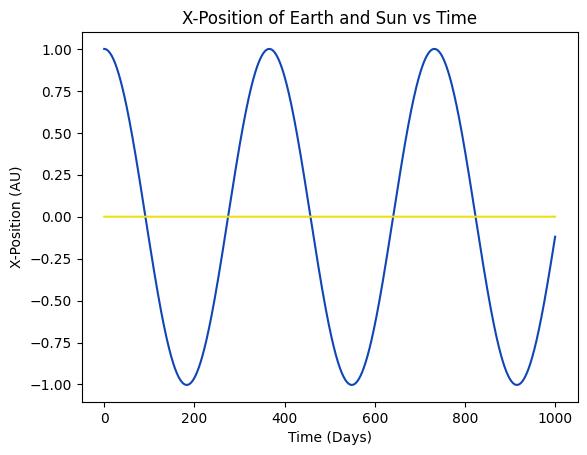

In [ ]:
# x-position vs time plot, covert to au and days

plt.plot((timesES/(24*60*60)),(positionsES[:,0,0]/1.496e+11), c='#0e46b5') #earth
plt.plot((timesES/(24*60*60)),(positionsES[:,1,0]/1.496e+11), c='#ebe013') #sun
#labels
plt.xlabel('Time (Days)')
plt.ylabel('X-Position (AU)')
plt.title('X-Position of Earth and Sun vs Time')

(np.float64(-1.1028704946221746),
 np.float64(1.1001186369988152),
 np.float64(-1.1014934769179938),
 np.float64(1.1014935523953313))

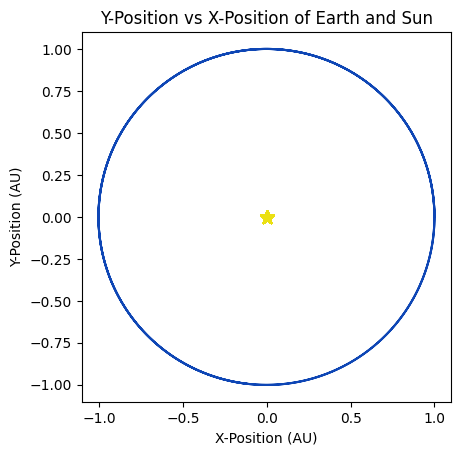

In [ ]:
# y-position vs x-position (trajectory), convert to au and days

plt.plot((positionsES[:,0,0]/1.496e+11),(positionsES[:,0,1]/1.496e+11), c='#0e46b5') #earth
plt.plot((positionsES[:,1,0]/1.496e+11),(positionsES[:,1,1]/1.496e+11), c='#ebe013', marker= '*', markersize= 10) #sun
#labels
plt.xlabel('X-Position (AU)')
plt.ylabel('Y-Position (AU)')
plt.title('Y-Position vs X-Position of Earth and Sun')
plt.axis('scaled') #set ratio

Text(0.5, 1.0, 'X-Velocity of Sun vs Time')

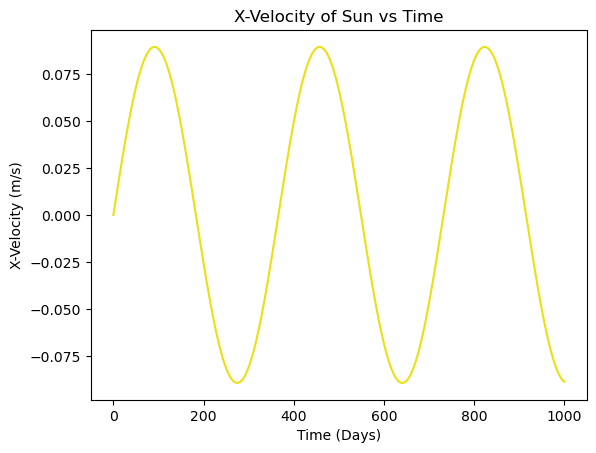

In [ ]:
# x-velocity vs time, convert to au and days

plt.plot((timesES/(24*60*60)),(velocitiesES[:,1,0]), c='#ebe013') #sun
plt.xlabel('Time (Days)')
plt.ylabel('X-Velocity (m/s)')
plt.title('X-Velocity of Sun vs Time')

### 6.6 (Modified Velocity Earth + Sun Plots)

In [ ]:
#new trajectories with velocity divided by 2
timesES, positionsES, velocitiesES = calculateTrajectories(ESmasses, ESinit_positions, (ESinit_velocities/2), EStime, ESstepsize)

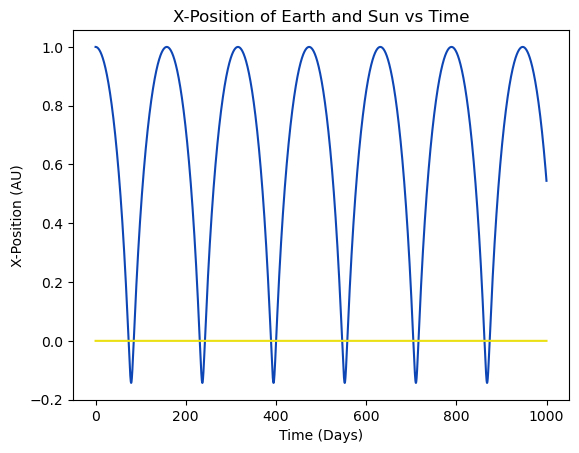

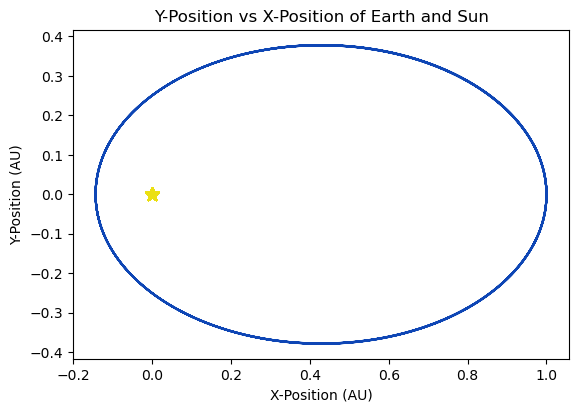

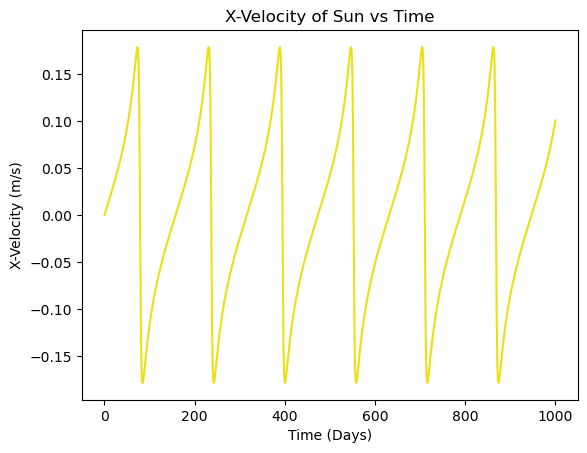

In [ ]:
#plots

# x-position vs time plot, covert to au and days
plt.plot((timesES/(24*60*60)),(positionsES[:,0,0]/1.496e+11), c='#0e46b5') #earth
plt.plot((timesES/(24*60*60)),(positionsES[:,1,0]/1.496e+11), c='#ebe013') #sun
#labels
plt.xlabel('Time (Days)')
plt.ylabel('X-Position (AU)')
plt.title('X-Position of Earth and Sun vs Time')
plt.show()

# y-position vs x-position (trajectory), convert to au and days
plt.plot((positionsES[:,0,0]/1.496e+11),(positionsES[:,0,1]/1.496e+11), c='#0e46b5') #earth
#making the sun a bit bigger with a different marker since it was hard to see before
plt.plot((positionsES[:,1,0]/1.496e+11),(positionsES[:,1,1]/1.496e+11), c='#ebe013', marker= '*', markersize=10) #sun
#labels
plt.xlabel('X-Position (AU)')
plt.ylabel('Y-Position (AU)')
plt.title('Y-Position vs X-Position of Earth and Sun')
plt.axis('scaled') #set ratio
plt.show()

# x-velocity vs time, convert to au and days
plt.plot((timesES/(24*60*60)),(velocitiesES[:,1,0]), c='#ebe013') #sun
plt.xlabel('Time (Days)')
plt.ylabel('X-Velocity (m/s)')
plt.title('X-Velocity of Sun vs Time')
plt.show()

How does the orbit change?

    Sun's orbit is pointier, and reflects how close Earth gets to it. (The pull on the sun from the earth due to gravity)
    Earth's orbit is more elliptical, and as a result has periods of time in its orbit where it is close to the sun and periods where it is far from the sun, versus having nearly the same distance from the sun throughout its orbit like in reality.

### 7.7 (Kepler16 Code)

In [ ]:
#reading in kepler16

kepler16 = pd.read_csv('kepler16.txt', sep=' ', comment='#', names= ['Mass (kg)', 'x (m)', 'y (m)', 'z (m)', 'Vx (m)', 'Vy (m)', 'Vz (m)'])

In [ ]:
print(kepler16['z (m)'])

0    1.844700e+09
1   -6.281300e+09
2    8.193400e+10
Name: z (m), dtype: float64


In [ ]:
#using table indexing to create arrays of starting positions and velocities

#empty list to populate
kepler16_init_positions = []
kepler16_init_velocities = []
for i in range(len(kepler16['x (m)'])): #parallel lists, so it doesn't matter which list I use here
    #appending each list with an array of positions for each particle
    kepler16_init_positions.append(np.array([kepler16['x (m)'] [i], kepler16['y (m)'] [i], kepler16['z (m)'] [i]]))
    kepler16_init_velocities.append(np.array([kepler16['Vx (m)'] [i], kepler16['Vy (m)'] [i], kepler16['Vz (m)'] [i]]))

#converting to arrays
kepler16_init_positions = np.array(kepler16_init_positions)
kepler16_init_velocities = np.array(kepler16_init_velocities)

#checking that it is organized how I want
print(kepler16_init_positions)
print(kepler16_init_velocities.shape)
print(kepler16['Mass (kg)'])
print(kepler16_init_positions[:,0])
# so particle, position

[[ 7.6349e+09 -9.6587e+05  1.8447e+09]
 [-2.5998e+10  3.2889e+06 -6.2813e+09]
 [ 3.7761e+10 -4.0923e+07  8.1934e+10]]
(3, 3)
0    1.371800e+30
1    4.028700e+29
2    6.325000e+26
Name: Mass (kg), dtype: float64
[ 7.6349e+09 -2.5998e+10  3.7761e+10]


rows = particle; columns = x,y,z etc;

### 7.8 (Kepler16 X-Z Plot)

In [ ]:
print(kepler16_init_positions[:,0])

[ 7.6349e+09 -2.5998e+10  3.7761e+10]


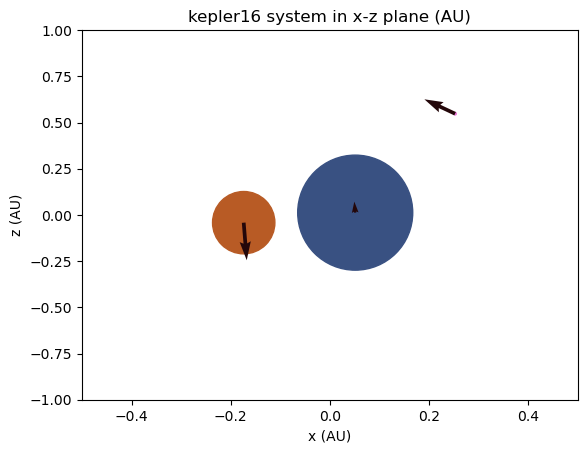

In [ ]:
# z is on the y-axis, x on the x-axis
area = kepler16['Mass (kg)']

#divide everything by 1.496e+11 to put it into terms of AU
plt.scatter(kepler16_init_positions[:,0]/1.496e+11, kepler16_init_positions[:,2]/1.496e+11, s=area/2e26, c=['#395182', '#b85b25', '#ed79d8']) #x, z positions
plt.quiver(kepler16_init_positions[:,0]/1.496e+11, kepler16_init_positions[:,2]/1.496e+11, kepler16_init_velocities [:,0]/1.496e+11, kepler16_init_velocities [:,2]/1.496e+11, color='#24070a') #x, z velocities

#labels
plt.xlabel('x (AU)')
plt.ylabel('z (AU)')
plt.title('kepler16 system in x-z plane (AU)')

#scale stuff
plt.xlim(-0.5, 0.5)
plt.ylim(-1,1)
#plt.axis('equal')
plt.show()

### 7.9 (Kepler16 Period + Orbit)

In [ ]:
t = (500*24*60*60) #(s)
tstep = (0.5*24*60*60) #(s)

# print(kepler16_init_positions.shape)

kepler16_times, kepler16_positions, kepler16_velocities = calculateTrajectories(np.array(kepler16['Mass (kg)']), kepler16_init_positions, kepler16_init_velocities, t, tstep)

# print(kepler16_velocities[:10, :, :])

In [ ]:
#checking array organization
kepler16_positions[0,:,0] #should be initial x positions for each particle

#first slot is time, second is particle, and third is position value

array([ 7.6349e+09, -2.5998e+10,  3.7761e+10])

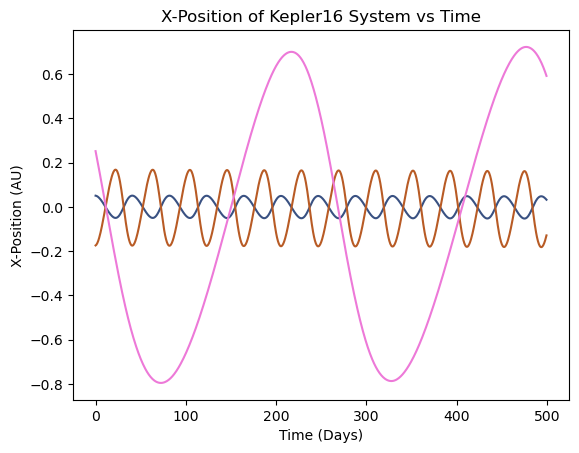

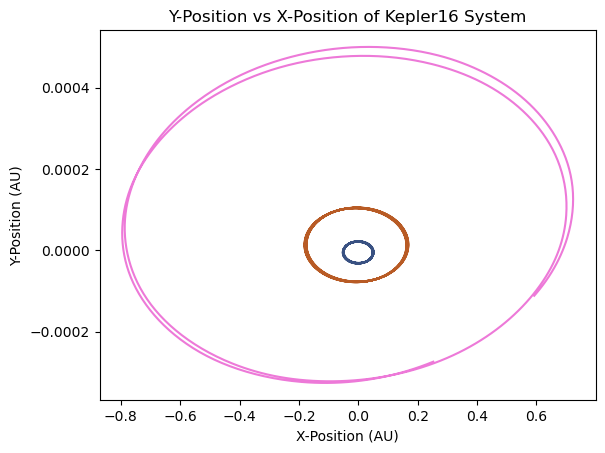

2.242166169407232e-05
-3.202031346600737e-05


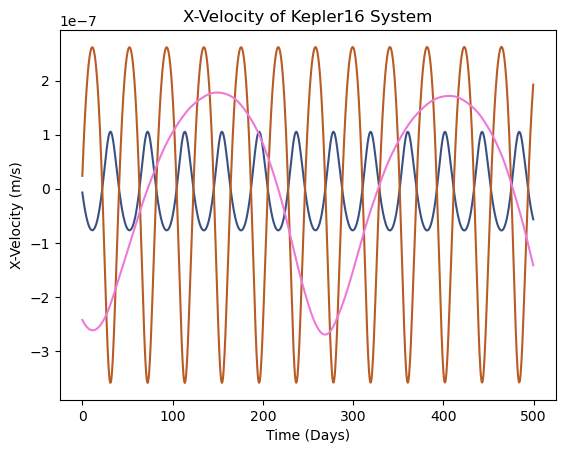

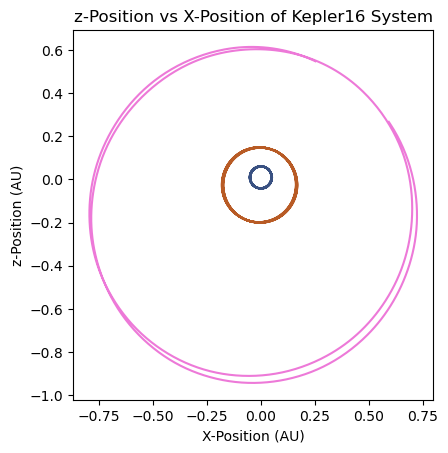

In [ ]:
# x-position vs time plot, covert to au and days
plt.plot((kepler16_times/(24*60*60)),(kepler16_positions[:,0,0]/1.496e+11), c='#395182') #first particle
plt.plot((kepler16_times/(24*60*60)),(kepler16_positions[:,1,0]/1.496e+11), c='#b85b25') #second particle
plt.plot((kepler16_times/(24*60*60)),(kepler16_positions[:,2,0]/1.496e+11), c='#ed79d8') #third particle
#labels
plt.xlabel('Time (Days)')
plt.ylabel('X-Position (AU)')
plt.title('X-Position of Kepler16 System vs Time')
plt.show()

# y-position vs x-position (trajectory), convert to au and days
# [_,_,0] = x, [_,_,1] = y
plt.plot((kepler16_positions[:,0,0]/1.496e+11),(kepler16_positions[:,0,1]/1.496e+11), c='#395182')
plt.plot((kepler16_positions[:,1,0]/1.496e+11),(kepler16_positions[:,1,1]/1.496e+11), c='#b85b25')
plt.plot((kepler16_positions[:,2,0]/1.496e+11),(kepler16_positions[:,2,1]/1.496e+11), c='#ed79d8')
#labels
plt.xlabel('X-Position (AU)')
plt.ylabel('Y-Position (AU)')
plt.title('Y-Position vs X-Position of Kepler16 System')
plt.show()

print((np.max(kepler16_positions[:,0,1]))/1.496e+11)
print((np.min(kepler16_positions[:,0,1]))/1.496e+11)

# x-velocity vs time, convert to au and days
plt.plot((kepler16_times/(24*60*60)),(kepler16_velocities[:,0,0]/1.496e+11), c='#395182')
plt.plot((kepler16_times/(24*60*60)),(kepler16_velocities[:,1,0]/1.496e+11), c='#b85b25')
plt.plot((kepler16_times/(24*60*60)),(kepler16_velocities[:,2,0]/1.496e+11), c='#ed79d8')
plt.xlabel('Time (Days)')
plt.ylabel('X-Velocity (m/s)')
plt.title('X-Velocity of Kepler16 System')
plt.show()

# z-position vs x-position (trajectory), convert to au and days
# [_,_,0] = x, [_,_,1] = y
plt.plot((kepler16_positions[:,0,0]/1.496e+11),(kepler16_positions[:,0,2]/1.496e+11), c='#395182')
plt.plot((kepler16_positions[:,1,0]/1.496e+11),(kepler16_positions[:,1,2]/1.496e+11), c='#b85b25')
plt.plot((kepler16_positions[:,2,0]/1.496e+11),(kepler16_positions[:,2,2]/1.496e+11), c='#ed79d8')
#labels
plt.xlabel('X-Position (AU)')
plt.ylabel('z-Position (AU)')
plt.title('z-Position vs X-Position of Kepler16 System')
plt.axis('scaled') #set ratio
plt.show()

### 7.10 (Kepler16 Animation)

In [ ]:
#checking stuff
print(kepler16_positions[:2,:2,:2])

[[[ 7.63490000e+09 -9.65870000e+05]
  [-2.59980000e+10  3.28890000e+06]]

 [[ 7.56917500e+09 -1.25802475e+06]
  [-2.57741936e+10  4.28370829e+06]]]


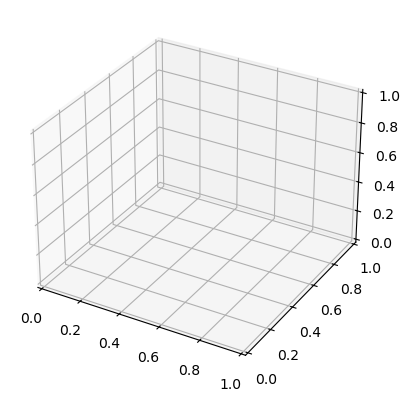

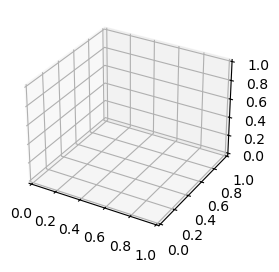

In [ ]:
ax = plt.axes(projection='3d')

FFMpegWriter = ani.writers['ffmpeg']
writer = FFMpegWriter(fps=40)

kepler16_days = (kepler16_times)/(24*60*60)

fig = plt.figure(figsize=(4,3))
fig.patch.set_alpha(1.0) # python bug fix
ax = plt.axes(projection='3d')

# write plots to frames of an animation
with writer.saving(fig, "Kepler16_3D.mp4", 200):
    for f in range(len(kepler16_days)):
        #positions for particle 0
        zline = (kepler16_positions[f,0,2])/1.496e+11
        xline = (kepler16_positions[f,0,0])/1.496e+11
        yline = (kepler16_positions[f,0,1])/1.496e+11
        ax.scatter3D(xline, yline, zline, 'blue')
        #positions for particle 1
        zline = (kepler16_positions[f,1,2])/1.496e+11
        xline = (kepler16_positions[f,1,0])/1.496e+11
        yline = (kepler16_positions[f,1,1])/1.496e+11
        ax.scatter3D(xline, yline, zline, 'orange')
        #positions for particle 2
        zline = (kepler16_positions[f,2,2])/1.496e+11
        xline = (kepler16_positions[f,2,0])/1.496e+11
        yline = (kepler16_positions[f,2,1])/1.496e+11
        ax.scatter3D(xline, yline, zline, 'pink')

        ax.set_xlabel('x (AU)'); ax.set_ylabel('y (AU)'); ax.set_zlabel('z (AU)')

        ax.set_title(f'Kepler16 System: day {kepler16_days[f]:03.0f}')

        #ax.set_xlim((np.min(((kepler16_positions[:][:][0])/1.496e+11)*2)), np.max(((kepler16_positions[:][:][0])/1.496e+11)*2))
        #ax.set_ylim((np.min(((kepler16_positions[:][:][1])/1.496e+11)*2)), np.max(((kepler16_positions[:][:][1])/1.496e+11)*2))
        #ax.set_zlim((np.min(((kepler16_positions[:][:][2])/1.496e+11)*2)), np.max(((kepler16_positions[:][:][2])/1.496e+11)*2))

        ax.set_xlim(-1,1)
        ax.set_ylim(-1,1)
        ax.set_zlim(-1,1)

        writer.grab_frame()

        plt.cla()

In [ ]:
from IPython.display import Video
Video("Kepler16_3D.mp4", embed=True)

### 8.11 Random Stars Around SM Blackhole Calculations

##### Sources
1) https://ui.adsabs.harvard.edu/abs/2017IAUS..316...84N/abstract
2) https://www.aanda.org/articles/aa/full_html/2014/10/aa23777-14/aa23777-14.html
3) https://en.wikipedia.org/wiki/Stellar_mass

In [ ]:
def generateSM_system(N):
    '''
    Generates N number of low-mass stars around a supermassive blackhole.
    ------
    Input:
            N = number of stars orbiting SM blackhole
    ------
    Output:
            Mass of SM blackhole, positioned at origin
            1D array of star masses + blackhole (kg)
            2D array of star initial positions + blackhole (meters)
            2D array of star initial velocities + blackhole (m/s)
    '''
    Mo = 1.989e30 #mass of sun, or solar mass

    # 1 pc =  3.09 × 10^16 meters

    #SUPERMASSIVE BLACKHOLE
    SM_mass= np.array((np.random.randint(1e6,1e9+1))*Mo) #creates a random mass value between 1e6 and 1e9 kg and then *sun mass
    SM_pos= np.array([0.,0.,0.]) #centered at origin
    SM_vel= np.array([0.,0.,0.]) #will not move

    #STAR MASSES
    #range is low mass stars to massive stars within 150 Mo(source 3, im not including special cases like R136a1)

    masses = [SM_mass] #I want the blackhole to be my 0th element

    for i in range(N):
        m = np.array((np.random.randint(0.08,150.0000001))*Mo) #including highlim
        masses.append(m) #I get an out of range error if I multiply by Mo in limits

    masses = np.array(masses)


    #STAR POSITIONS

    lim_p = 1*3.09e16 #within 1 parsec radius
    #with this project's scope and computation abilities, 1 parsec will do

    m_init_positions = [SM_pos]

    for i in range(N):
        x =  np.random.randint(-lim_p,lim_p)
        y =  np.random.randint(-lim_p,lim_p)
        z =  np.random.randint(-lim_p,lim_p)

        pos = np.array([x,y,z]) #shape is 3
        m_init_positions.append(pos)

    m_init_positions = np.array(m_init_positions)


    #STAR VELOCITIES

    #using algorithms from Tatsuya
    from scipy.stats import maxwell #using Maxwell-Boltzmann distribution for speed

    center = 1e6 #typical speed, 1000 km
    spread = 1e2 #spread in speed, order of 100

    m_init_velocities = [SM_vel]

    for i in range(N):

        velocity = maxwell.rvs(center, spread)

        #this algorithm generates a vector pointing in a random direction in 3D space

        theta = np.arccos(np.random.uniform(low=-1.0, high=1.0)) #random polar angle
        phi = np.random.uniform(low=0.0, high=2*np.pi) #random azimuthal angle
        #velocity = magnitude

        #convert from spherical to Cartesian coordinates
        vector = np.array([velocity*np.sin(theta)*np.cos(phi), velocity*np.sin(theta)*np.sin(phi), velocity*np.cos(theta)])

        m_init_velocities.append(vector)

    m_init_velocities = np.array(m_init_velocities)

    return masses, m_init_positions, m_init_velocities

In [ ]:
model_masses, init_model_positions, init_model_velocities = generateSM_system(20)
#making it easy to see
print('Masses')
print(type(model_masses))
print(model_masses.shape) #should be a 1D array
print(model_masses)
print('')
print('Initial Positions')
print(type(init_model_positions))
print(init_model_positions.shape)
print(init_model_positions)
print('')
print('Initial Velocities')
print(type(init_model_positions))
print(init_model_velocities.shape)
print(init_model_velocities)

Masses
<class 'numpy.ndarray'>
(21,)
[1.89184841e+39 8.55270000e+31 1.25307000e+32 2.40669000e+32
 1.35252000e+32 2.42658000e+32 2.40669000e+32 5.37030000e+31
 2.26746000e+32 2.58570000e+32 1.45197000e+32 1.69065000e+32
 2.56581000e+32 2.34702000e+32 1.39230000e+31 2.46636000e+32
 2.28735000e+32 2.04867000e+32 1.25307000e+32 1.13373000e+32
 2.74482000e+32]

Initial Positions
<class 'numpy.ndarray'>
(21, 3)
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 2.02024635e+16  1.49895519e+14 -2.30868087e+16]
 [ 2.38051274e+16 -2.83218382e+14 -1.64904269e+16]
 [ 3.76519052e+15 -4.55370611e+15 -2.54115464e+16]
 [ 1.48298408e+16  2.54035687e+15  1.20279156e+16]
 [ 2.40162080e+16  8.54911099e+15 -2.11418007e+16]
 [ 2.42342308e+16 -2.07692153e+15  6.93076976e+15]
 [-9.27958841e+15  2.95728772e+15 -2.51593960e+16]
 [ 2.19232037e+16  1.97010060e+16 -1.25214732e+16]
 [-1.21443788e+16 -1.74188274e+16 -1.42987598e+16]
 [ 2.16412114e+16 -1.06234553e+16  4.19134904e+15]
 [-1.59288557e+16 -3.76084696

In [ ]:
model_t = 365*5000*24*60*60 #5000 years in seconds
model_step = 365*24*60*60 #1 year in seconds
model_times, model_positions, model_velocities = calculateTrajectories(model_masses, init_model_positions, init_model_velocities, model_t, model_step)
print(model_times.shape)
print(model_positions.shape)
print(model_velocities.shape)
print('')

print(f'Times..:{model_times[:10]}')
print(type(model_times))
print('')
print(f'Positions...:{model_positions[:10,1,:]}')
#print(type(model_positions))
print('')
print(f'Velocities...:{model_velocities[:10,1,:]}')
#print(type(model_velocities))

(5000,)
(5000, 21, 3)
(5000, 21, 3)

Times..:[        0  31536000  63072000  94608000 126144000 157680000 189216000
 220752000 252288000 283824000]
<class 'numpy.ndarray'>

Positions...:[[-1.69366560e+16  1.19427325e+16 -2.27984177e+16]
 [-1.69070034e+16  1.19323004e+16 -2.28011271e+16]
 [-1.68773290e+16  1.19218529e+16 -2.28038073e+16]
 [-1.68476329e+16  1.19113902e+16 -2.28064582e+16]
 [-1.68179151e+16  1.19009121e+16 -2.28090797e+16]
 [-1.67881756e+16  1.18904186e+16 -2.28116717e+16]
 [-1.67584145e+16  1.18799097e+16 -2.28142343e+16]
 [-1.67286316e+16  1.18693855e+16 -2.28167673e+16]
 [-1.66988270e+16  1.18588459e+16 -2.28192707e+16]
 [-1.66690007e+16  1.18482908e+16 -2.28217444e+16]]

Velocities...:[[ 939936.01620529 -330557.9184563   -86379.44168997]
 [ 940624.16995915 -331043.37419286  -85452.24235888]
 [ 941312.34575396 -331529.27284105  -84523.27529468]
 [ 942000.54253345 -332015.61518182  -83592.53570416]
 [ 942688.75923266 -332502.40199716  -82660.0187763 ]
 [ 943376.99477789

### 8.12 Model 3D Animation

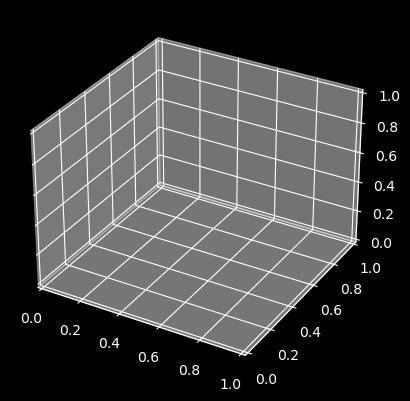

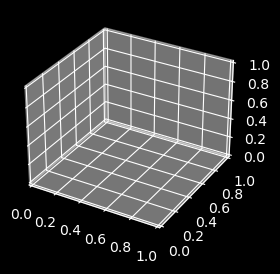

In [ ]:
ax = plt.axes(projection='3d')

FFMpegWriter = ani.writers['ffmpeg']
writer = FFMpegWriter(fps=40)

model_days = (model_times)/(365*24*60*60)

plt.style.use('dark_background')

fig = plt.figure(figsize= (3,4)) #I want the background to be black
fig.patch.set_alpha(1.0) # python bug fix
ax = plt.axes(projection='3d')

# write plots to frames of an animation
with writer.saving(fig, "SM_Model_3D.mp4", 200):
    for f in range(len(model_days)): #for each frame
        for i in range(len(model_masses)): #for each particle
            if i == 0: #black hole
                zline = (model_positions[f,0,2])/1.496e+11
                xline = (model_positions[f,0,0])/1.496e+11
                yline = (model_positions[f,0,1])/1.496e+11
                #I want the blackhole nearly invisible
                ax.scatter3D(xline, yline, zline, 'black', s=(model_masses[0]/1.5e36), alpha=0.5, edgecolor='none')
            else:
                zline = (model_positions[f,i,2])/1.496e+11
                xline = (model_positions[f,i,0])/1.496e+11
                yline = (model_positions[f,i,1])/1.496e+11

                #plotting the stars
                ax.scatter3D(xline, yline, zline, '#ffff80', s=((model_masses[i]/1e31)*5), marker='*')


        ax.set_xlabel('X (AU)'); ax.set_ylabel('Y (AU)'); ax.set_zlabel('Z (AU)')

        ax.set_title(f'SM Model System: Year {(model_days[f]):4.0f}')


        ax.set_xlim(-3.4e5,3.4e5) #1 parsec = 206265 AU
        ax.set_ylim(-3.4e5,3.4e5)
        ax.set_zlim(-3.4e5,3.4e5)

        writer.grab_frame()

        plt.cla()


In [ ]:
from IPython.display import Video
Video("SM_Model_3D.mp4", embed=True)